# 📈 Modelagem - Regressão Linear

Este notebook utiliza a base tratada salva em `data/processed/credit_processed.csv`
para construir e avaliar um modelo baseline de regressão linear.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
DATA_PATH = Path("../data/processed/credit_processed.csv")
df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(400, 14)


,Income,Limit,Rating,Cards,Age,Education,Balance,debt_to_income,cards_per_age,Gender_Female,Student_Yes,Married_Yes,Ethnicity_Asian,Ethnicity_Caucasian
0,14.891,3606,283,2,34,11,333,20.955258,0.057143,False,False,True,False,True
1,106.025,6645,483,3,82,15,903,8.437281,0.036145,True,True,True,True,False
2,104.593,7075,514,4,71,11,580,5.492788,0.055556,False,False,False,True,False
3,148.924,9504,681,3,36,11,964,6.429924,0.081081,True,False,False,True,False
4,55.882,4897,357,2,68,16,331,5.819064,0.028986,False,False,True,False,True


## 1. Separação entre features e target

In [3]:
target = "Limit"

X = df.drop(columns=[target])
y = df[target]

print("X:", X.shape)
print("y:", y.shape)

X: (400, 13)
y: (400,)


## 2. Split treino e teste

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Treino:", X_train.shape, y_train.shape)
print("Teste:", X_test.shape, y_test.shape)

Treino: (300, 13) (300,)
Teste: (100, 13) (100,)


## 3. Treinamento do baseline

In [5]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 4. Predições

In [6]:
y_pred_train = model_lr.predict(X_train)
y_pred_test = model_lr.predict(X_test)

## 5. Avaliação

In [7]:
def regression_metrics(y_true, y_pred, label="conjunto"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{label} -> MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")

regression_metrics(y_train, y_pred_train, "Treino")
regression_metrics(y_test, y_pred_test, "Teste")

Treino -> MAE: 118.0707 | RMSE: 144.7193 | R²: 0.9963
Teste -> MAE: 117.3700 | RMSE: 146.3133 | R²: 0.9947


## 6. Coeficientes

In [8]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coeficiente": model_lr.coef_
}).sort_values("coeficiente", ascending=False)

coef_df.head(15)

,feature,coeficiente
11,Ethnicity_Asian,35.616183
12,Ethnicity_Caucasian,15.290936
1,Rating,13.202724
8,Gender_Female,5.526377
0,Income,3.567047
4,Education,3.254738
6,debt_to_income,1.145731
5,Balance,0.412877
3,Age,-0.756556
10,Married_Yes,-30.361255


In [9]:
coef_df.tail(15)

,feature,coeficiente
11,Ethnicity_Asian,35.616183
12,Ethnicity_Caucasian,15.290936
1,Rating,13.202724
8,Gender_Female,5.526377
0,Income,3.567047
4,Education,3.254738
6,debt_to_income,1.145731
5,Balance,0.412877
3,Age,-0.756556
10,Married_Yes,-30.361255


## 7. Gráficos diagnósticos

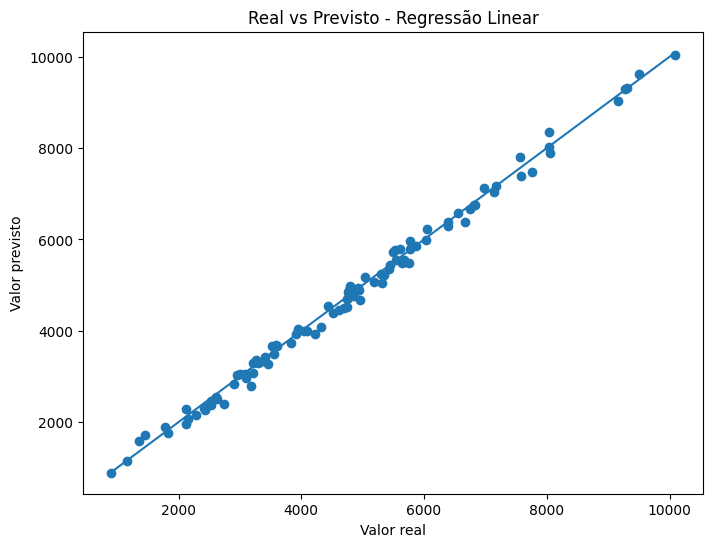

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test)
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title("Real vs Previsto - Regressão Linear")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

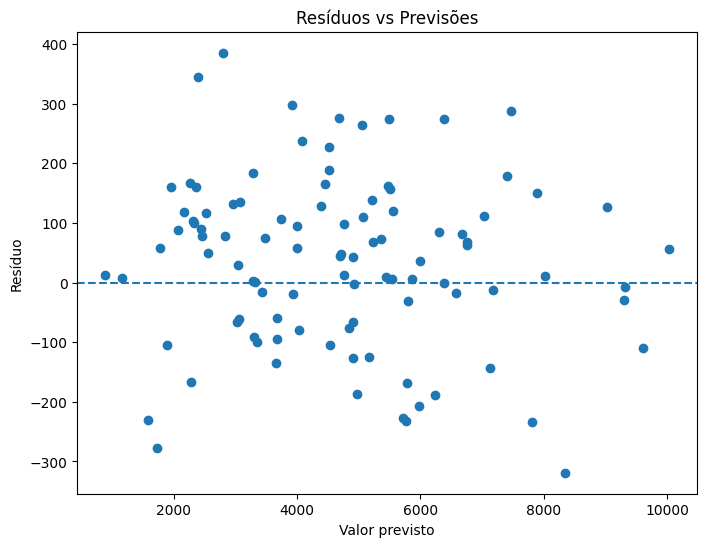

In [11]:
residuos = y_test - y_pred_test

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_test, residuos)
plt.axhline(0, linestyle="--")
plt.xlabel("Valor previsto")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Previsões")
plt.show()

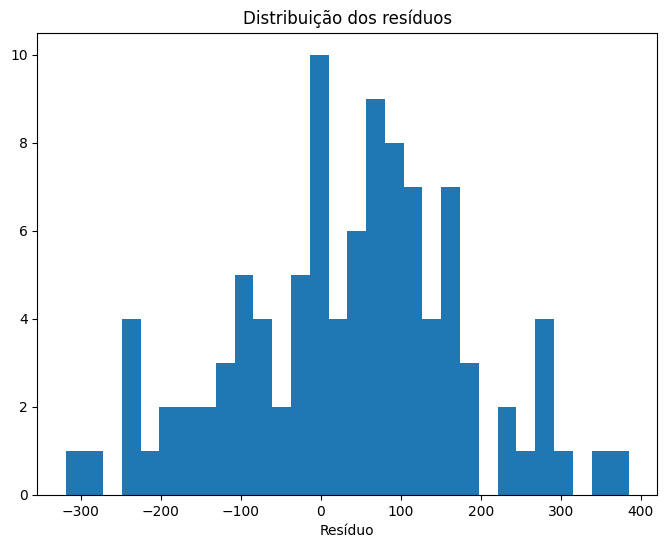

In [12]:
plt.figure(figsize=(8, 6))
plt.hist(residuos, bins=30)
plt.title("Distribuição dos resíduos")
plt.xlabel("Resíduo")
plt.show()

# Análise posterior

Como o modelo deu um R^2 muito alto, vamos verificar se não a leakage

Leakage acontece quando o modelo usa informações que: não estariam disponíveis no momento da previsão
ou estão diretamente relacionadas ao target (Limit)

In [15]:
corr = df.corr(numeric_only=True)["Limit"].sort_values(ascending=False)
print(corr)

Limit                  1.000000
Rating                 0.996880
Balance                0.861697
Income                 0.792088
debt_to_income         0.250721
Age                    0.100888
Married_Yes            0.031155
Cards                  0.010231
Gender_Female          0.009397
Ethnicity_Caucasian   -0.003081
Student_Yes           -0.006015
Education             -0.023549
cards_per_age         -0.027397
Ethnicity_Asian       -0.032427
Name: Limit, dtype: float64


In [16]:
for col in X.columns:
    model = LinearRegression()
    model.fit(X[[col]], y)
    r2 = model.score(X[[col]], y)
    print(f"{col}: {r2:.4f}")

Income: 0.6274
Rating: 0.9938
Cards: 0.0001
Age: 0.0102
Education: 0.0006
Balance: 0.7425
debt_to_income: 0.0629
cards_per_age: 0.0008
Gender_Female: 0.0001
Student_Yes: 0.0000
Married_Yes: 0.0010
Ethnicity_Asian: 0.0011
Ethnicity_Caucasian: 0.0000


In [18]:
cols_suspeitas = ["Balance", "Rating"]

X_reduced = X.drop(columns=cols_suspeitas)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

model_r = LinearRegression()
model_r.fit(X_train_r, y_train_r)

y_pred_test_r = model_r.predict(X_test_r)

from sklearn.metrics import r2_score

r2_reduced = r2_score(y_test_r, y_pred_test_r)
print("R² sem variáveis suspeitas:", r2_reduced)

R² sem variáveis suspeitas: 0.837495060958054


Claramente detectamos leakage pelas variáveis Balance e Rating, que estavam muito correlacionadas com o variável target.
Próximo passo então é refazer o modelo sem essas variáveis

### Por que houve leakage nesse caso?

Alta correlação entre variável e target geralmente é algo positivo, a não ser quando ela vem de leakage.
Esse cenário ocorre quando:
❌ a variável é consequência do target
❌ ou contém informação “do futuro”

Pensando em um exemplo do nesse projeto:

❌ Balance
O cliente tem limite de 5000
Ele gasta 3000 → vira Balance

Ou seja:

Balance depende do Limit

Agora o modelo aprende:

"Se Balance é alto → Limit deve ser alto"

Mas isso é trapaça, porque: você só conhece o balance DEPOIS de dar o limite

❌ Rating

Se for um score interno:

Ele já foi usado para definir o limite

Então o modelo está basicamente fazendo: prever Limit usando algo que já definiu o Limit

## Definindo uma nova abordagem, modelo válido

In [19]:
cols_validas = [col for col in X.columns if col not in ["Balance", "Rating"]]
X_valid = X[cols_validas]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_valid, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R²: 0.837495060958054
MAE: 619.5611350684488
RMSE: 767.1818174461858


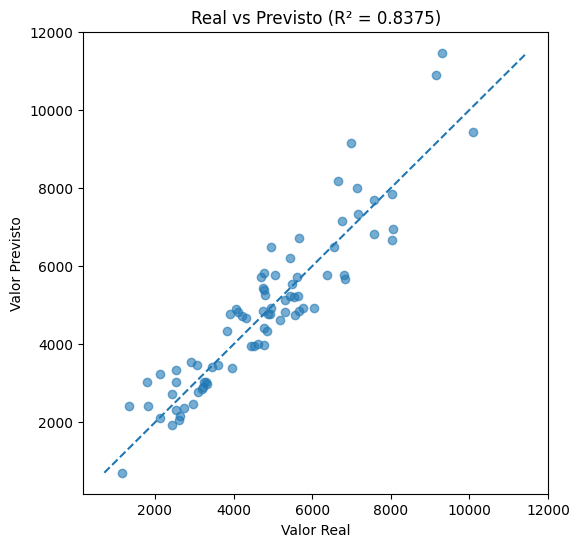

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

# scatter (pontos reais vs previstos)
plt.scatter(y_test, y_pred, alpha=0.6)

# linha perfeita (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

# labels
plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title(f"Real vs Previsto (R² = {r2:.4f})")

plt.show()